# Artemis II: Mengikuti Perjalanan Orion ke Bulan dengan Data NASA

> *"Integrity"* — nama panggilan kapsul Orion yang dipilih kru Artemis II

Pada **1 April 2026 pukul 22:35:12 UTC**, roket SLS mengangkat empat astronaut dari Kennedy Space Center menuju Bulan. Misi Artemis II bukan pendaratan — ia adalah *dress rehearsal*: membuktikan bahwa Orion dan sistemnya siap membawa manusia ke permukaan Bulan di misi berikutnya.

Notebook ini menggunakan data ephemeris nyata dari **NASA JPL Horizons** untuk merekonstruksi dan memvisualisasikan trajektori perjalanan kapsul Orion ("Integrity") dan posisi Bulan selama 9 hari misi.

**Kru:**
- Reid Wiseman — Commander
- Victor Glover — Pilot  
- Christina Koch — Mission Specialist
- Jeremy Hansen (CSA) — Mission Specialist

---

## 1. Setup dan Parsing Data Ephemeris

Data ephemeris NASA Horizons menggunakan format teks dengan penanda `$$SOE` (start of ephemeris) dan `$$EOE` (end of ephemeris). Setiap baris berisi:
- **JDTDB** — Julian Date (Barycentric Dynamical Time)
- **X, Y, Z** — posisi dalam km (referensi: Ekliptika J2000.0, pusat Bumi)
- **VX, VY, VZ** — kecepatan dalam km/s

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D
from datetime import datetime, timezone
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#000000',
    'axes.facecolor': '#000000',
    'axes.edgecolor': '#2a2a2a',
    'axes.labelcolor': '#F0F0F0',
    'xtick.color': '#AAAAAA',
    'ytick.color': '#AAAAAA',
    'text.color': '#F0F0F0',
    'grid.color': '#111111',
    'grid.linewidth': 0.5,
    'legend.facecolor': '#0A0A0A',
    'legend.edgecolor': '#2a2a2a',
    'font.family': 'sans-serif',
    'font.size': 10,
})

In [2]:
def parse_horizons(filepath):
    """Parse NASA Horizons ephemeris file, return DataFrame."""
    rows = []
    in_data = False
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line == '$$SOE':
                in_data = True
                continue
            if line == '$$EOE':
                break
            if not in_data or not line:
                continue
            parts = [p.strip() for p in line.split(',')]
            if len(parts) < 8:
                continue
            try:
                jd   = float(parts[0])
                date_str = parts[1].replace('A.D. ', '').strip()
                x, y, z   = float(parts[2]), float(parts[3]), float(parts[4])
                vx, vy, vz = float(parts[5]), float(parts[6]), float(parts[7])
                rows.append({'jd': jd, 'date_str': date_str,
                             'x': x, 'y': y, 'z': z,
                             'vx': vx, 'vy': vy, 'vz': vz})
            except ValueError:
                continue
    df = pd.DataFrame(rows)
    df['time'] = pd.to_datetime(df['date_str'], format='%Y-%b-%d %H:%M:%S.%f')
    return df.sort_values('time').reset_index(drop=True)

orion = parse_horizons('artemis_ephemeris.txt')
moon  = parse_horizons('moon_ephemeris.txt')

print(f"Orion : {len(orion)} titik | {orion['time'].iloc[0]} → {orion['time'].iloc[-1]}")
print(f"Bulan : {len(moon)} titik  | {moon['time'].iloc[0]} → {moon['time'].iloc[-1]}")

Orion : 2567 titik | 2026-04-02 01:58:32.305000 → 2026-04-10 23:48:32.305000
Bulan : 2567 titik  | 2026-04-02 01:58:32.305000 → 2026-04-10 23:48:32.305000


In [3]:
# Computed quantities
orion['dist_earth'] = np.sqrt(orion.x**2 + orion.y**2 + orion.z**2)
orion['speed']      = np.sqrt(orion.vx**2 + orion.vy**2 + orion.vz**2)

# Interpolate moon position to Orion timestamps
moon_x = np.interp(orion['jd'], moon['jd'], moon['x'])
moon_y = np.interp(orion['jd'], moon['jd'], moon['y'])
moon_z = np.interp(orion['jd'], moon['jd'], moon['z'])

orion['dist_moon'] = np.sqrt(
    (orion.x - moon_x)**2 +
    (orion.y - moon_y)**2 +
    (orion.z - moon_z)**2
)

print(f"Jarak maks dari Bumi  : {orion['dist_earth'].max():,.1f} km")
print(f"Jarak min dari Bulan  : {orion['dist_moon'].min():,.1f} km")
print(f"Kecepatan maks        : {orion['speed'].max():.3f} km/s")
print(f"Kecepatan min         : {orion['speed'].min():.3f} km/s")

Jarak maks dari Bumi  : 413,144.2 km
Jarak min dari Bulan  : 8,282.7 km
Kecepatan maks        : 10.654 km/s
Kecepatan min         : 0.414 km/s


## 2. Kejadian Penting Misi

Kita tandai setiap momen kritis dari timeline misi untuk overlaid di atas grafik.

In [4]:
events = [
    ('TLI Burn\n(+388 m/s)',     '2026-04-02 23:49', '#FF6B35'),
    ('OTC-3\n(+3 m/s)',          '2026-04-06 03:03', '#FFA040'),
    ('Masuk SOI Bulan',           '2026-04-06 05:38', '#FFD700'),
    ('Closest Approach\n8282 km', '2026-04-06 23:01', '#FF3300'),
    ('Max Jarak Bumi\n413,146 km','2026-04-06 23:05', '#FFAA00'),
    ('Keluar SOI Bulan',          '2026-04-07 16:23', '#FFD700'),
    ('Return Burn 1',             '2026-04-08 00:03', '#FFA040'),
    ('Return Burn 2',             '2026-04-10 01:53', '#FFA040'),
    ('Return Burn 3',             '2026-04-10 17:53', '#FFA040'),
    ('Entry Interface\n122 km',   '2026-04-10 23:53', '#00E5FF'),
    ('Splashdown',                '2026-04-11 00:07', '#00E5FF'),
]

events_df = pd.DataFrame(events, columns=['label', 'time_str', 'color'])
events_df['time'] = pd.to_datetime(events_df['time_str'])

def get_orion_at(target_time):
    """Interpolate Orion state at given timestamp."""
    t_jd = (pd.Timestamp(target_time) - pd.Timestamp('2000-01-01 12:00:00')).total_seconds() / 86400 + 2451545.0
    row = {}
    for col in ['x', 'y', 'z', 'dist_earth', 'dist_moon', 'speed']:
        row[col] = np.interp(t_jd, orion['jd'], orion[col])
    return row

events_df['orion'] = events_df['time'].apply(get_orion_at)

## 3. Trajektori Orion di Bidang Ekliptika (2D)

Berikut jejak Orion dalam koordinat X-Y (bidang ekliptika), Earth-centered. Bulan bergerak sepanjang misi, posisinya divisualisasikan di titik closest approach.

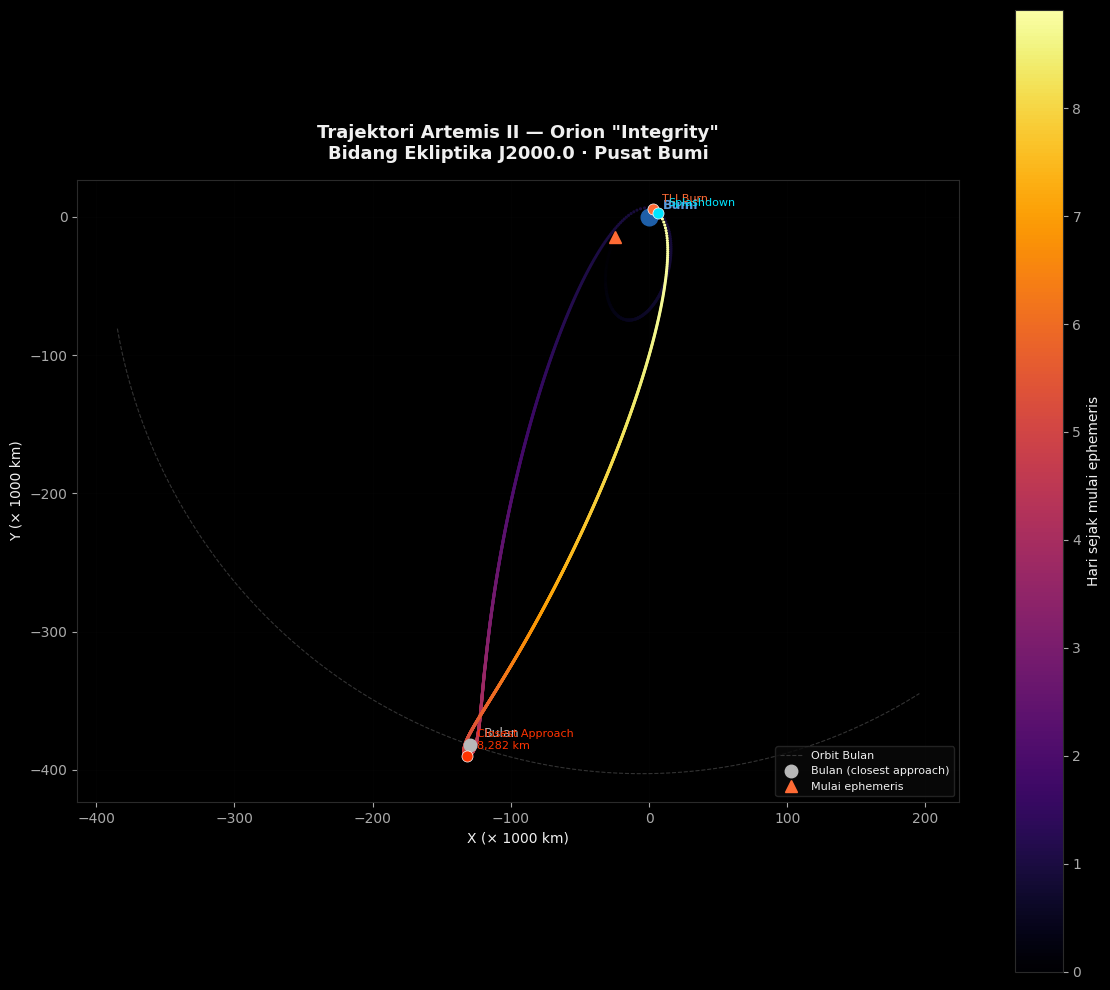

Disimpan: trajectory_2d.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 10))

# Color trajectory by mission day — inferno: black → red → orange → yellow
days = (orion['time'] - orion['time'].iloc[0]).dt.total_seconds() / 86400
sc = ax.scatter(orion['x'] / 1e3, orion['y'] / 1e3,
                c=days, cmap='inferno', s=1.5, zorder=2)
cbar = plt.colorbar(sc, ax=ax, label='Hari sejak mulai ephemeris')
cbar.ax.yaxis.label.set_color('#F0F0F0')
cbar.ax.tick_params(colors='#AAAAAA')

# Earth
ax.plot(0, 0, 'o', color='#1E5FA8', markersize=12, zorder=6)
ax.annotate('Bumi', (0, 0), textcoords='offset points', xytext=(10, 6),
            color='#5B9BDB', fontsize=9, fontweight='bold')

# Moon trajectory
ax.plot(moon['x'] / 1e3, moon['y'] / 1e3, '--', color='#555555',
        linewidth=0.8, alpha=0.6, label='Orbit Bulan')

# Moon at closest approach
ca_time = pd.Timestamp('2026-04-06 23:01')
ca_jd = (ca_time - pd.Timestamp('2000-01-01 12:00:00')).total_seconds() / 86400 + 2451545.0
mx = np.interp(ca_jd, moon['jd'], moon['x']) / 1e3
my = np.interp(ca_jd, moon['jd'], moon['y']) / 1e3
ax.plot(mx, my, 'o', color='#B8B8B8', markersize=9, zorder=6, label='Bulan (closest approach)')
ax.annotate('Bulan', (mx, my), textcoords='offset points', xytext=(10, 6),
            color='#B8B8B8', fontsize=9)

# Key events
key_events = [
    ('TLI Burn', '2026-04-02 23:49', '#FF6B35'),
    ('Closest Approach\n8,282 km', '2026-04-06 23:01', '#FF3300'),
    ('Splashdown', '2026-04-11 00:00', '#00E5FF'),
]
for label, t_str, color in key_events:
    r = get_orion_at(t_str)
    ax.plot(r['x'] / 1e3, r['y'] / 1e3, 'o', color=color, markersize=8,
            zorder=7, markeredgecolor='white', markeredgewidth=0.5)
    ax.annotate(label, (r['x'] / 1e3, r['y'] / 1e3),
                textcoords='offset points', xytext=(7, 5),
                color=color, fontsize=8)

# Start point
ax.plot(orion['x'].iloc[0] / 1e3, orion['y'].iloc[0] / 1e3,
        '^', color='#FF6B35', markersize=9, zorder=7, label='Mulai ephemeris')

ax.set_xlabel('X (× 1000 km)')
ax.set_ylabel('Y (× 1000 km)')
ax.set_title('Trajektori Artemis II — Orion "Integrity"\nBidang Ekliptika J2000.0 · Pusat Bumi',
             fontsize=13, pad=15, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('trajectory_2d.png', dpi=150, bbox_inches='tight', facecolor='#000000')
plt.show()
print("Disimpan: trajectory_2d.png")

## 4. Jarak Orion dari Bumi dan Bulan

Grafik ini menunjukkan bagaimana Orion menjauhi Bumi, mendekati Bulan, lalu kembali — sebuah manuver yang disebut **free-return trajectory**.

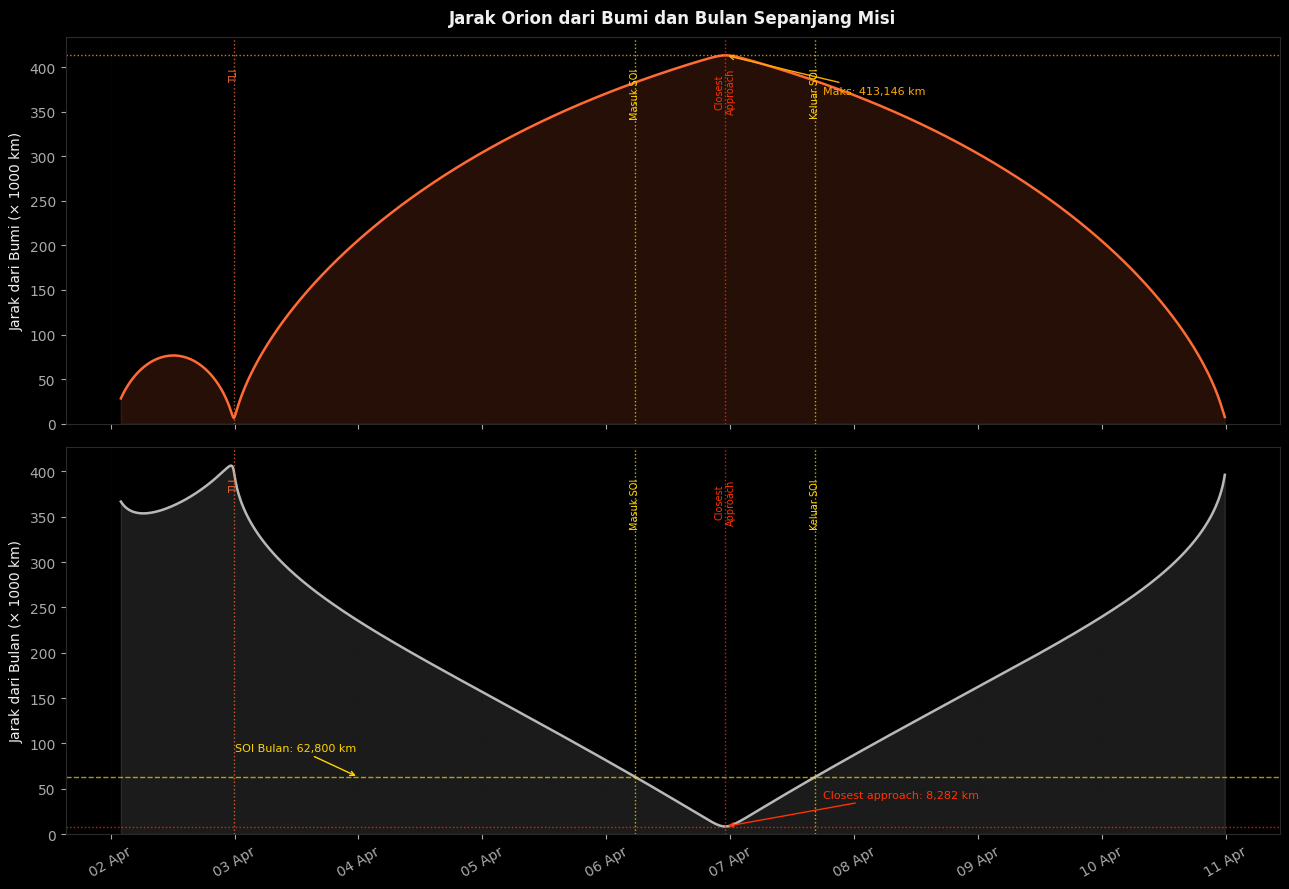

Disimpan: distance_profile.png


In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.patch.set_facecolor('#000000')

# --- Distance from Earth ---
ax1.fill_between(orion['time'], orion['dist_earth'] / 1e3, alpha=0.15, color='#FF6B35')
ax1.plot(orion['time'], orion['dist_earth'] / 1e3, color='#FF6B35', linewidth=1.8)
ax1.set_ylabel('Jarak dari Bumi (× 1000 km)')
ax1.set_title('Jarak Orion dari Bumi dan Bulan Sepanjang Misi',
              fontsize=12, pad=10, fontweight='bold')
ax1.axhline(413.146, color='#FFAA00', linestyle=':', linewidth=1, alpha=0.8)
ax1.annotate('Maks: 413,146 km', xy=(pd.Timestamp('2026-04-06 23:05'), 413.146),
             xytext=(pd.Timestamp('2026-04-07 18:00'), 370),
             arrowprops=dict(arrowstyle='->', color='#FFAA00'),
             color='#FFAA00', fontsize=8)
ax1.grid(True, alpha=0.2)
ax1.set_ylim(bottom=0)

# --- Distance from Moon ---
ax2.fill_between(orion['time'], orion['dist_moon'] / 1e3, alpha=0.15, color='#B8B8B8')
ax2.plot(orion['time'], orion['dist_moon'] / 1e3, color='#B8B8B8', linewidth=1.8)
ax2.set_ylabel('Jarak dari Bulan (× 1000 km)')
ax2.axhline(8.282, color='#FF3300', linestyle=':', linewidth=1, alpha=0.8)
ax2.annotate('Closest approach: 8,282 km', xy=(pd.Timestamp('2026-04-06 23:01'), 8.282),
             xytext=(pd.Timestamp('2026-04-07 18:00'), 40),
             arrowprops=dict(arrowstyle='->', color='#FF3300'),
             color='#FF3300', fontsize=8)
ax2.axhline(62.8, color='#FFD700', linestyle='--', linewidth=1, alpha=0.7)
ax2.annotate('SOI Bulan: 62,800 km', xy=(pd.Timestamp('2026-04-04 00:00'), 62.8),
             xytext=(pd.Timestamp('2026-04-03 00:00'), 92),
             arrowprops=dict(arrowstyle='->', color='#FFD700'),
             color='#FFD700', fontsize=8)
ax2.grid(True, alpha=0.2)
ax2.set_ylim(bottom=0)

# Event markers
event_times = {
    'TLI': pd.Timestamp('2026-04-02 23:49'),
    'Masuk SOI': pd.Timestamp('2026-04-06 05:38'),
    'Closest\nApproach': pd.Timestamp('2026-04-06 23:01'),
    'Keluar SOI': pd.Timestamp('2026-04-07 16:23'),
}
colors_ev = ['#FF6B35', '#FFD700', '#FF3300', '#FFD700']
for ax in [ax1, ax2]:
    ylim = ax.get_ylim()
    for (label, t), c in zip(event_times.items(), colors_ev):
        ax.axvline(t, color=c, linestyle=':', linewidth=1, alpha=0.8)
        ax.text(t, ylim[1] * 0.92, label, color=c, fontsize=7,
                ha='center', va='top', rotation=90)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d Apr'))
ax2.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('distance_profile.png', dpi=150, bbox_inches='tight', facecolor='#000000')
plt.show()
print("Disimpan: distance_profile.png")

## 5. Profil Kecepatan Orion

Kecepatan Orion mencerminkan mekanika orbital: **melambat saat menjauhi Bumi** (gravitasi menarik ke belakang), **mempercepat saat mendekati Bulan**, lalu **mempercepat lagi saat jatuh kembali ke Bumi**. Setiap burn mengubah kurva kecepatan.

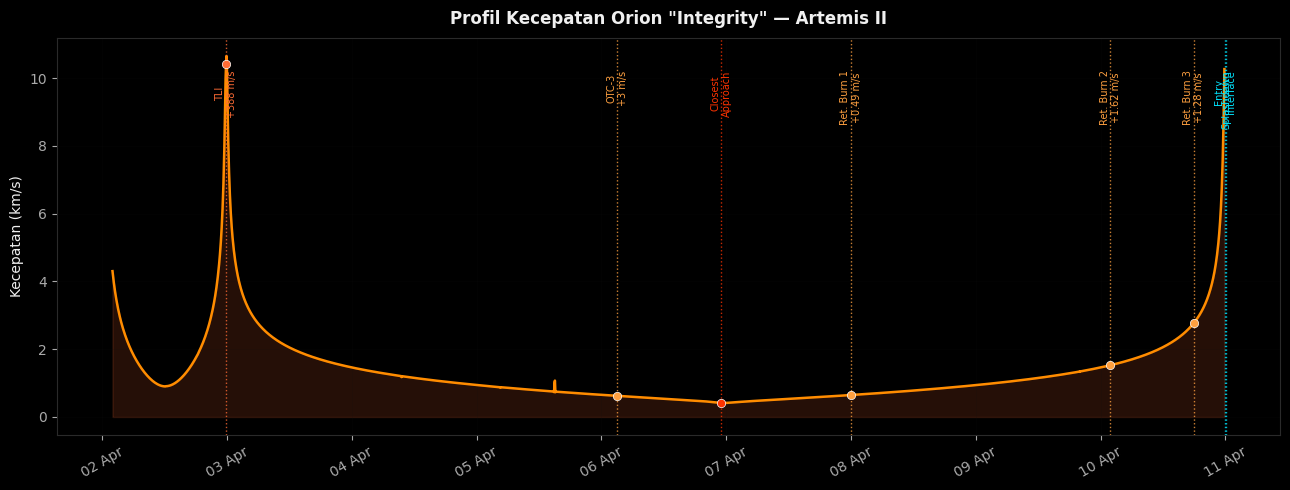

Disimpan: speed_profile.png


In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#000000')

ax.fill_between(orion['time'], orion['speed'], alpha=0.15, color='#FF6B35')
ax.plot(orion['time'], orion['speed'], color='#FF8C00', linewidth=1.8)

burn_events = [
    ('TLI\n+388 m/s',          '2026-04-02 23:49', '#FF6B35'),
    ('OTC-3\n+3 m/s',          '2026-04-06 03:03', '#FFA040'),
    ('Closest\nApproach',       '2026-04-06 23:01', '#FF3300'),
    ('Ret. Burn 1\n+0.49 m/s', '2026-04-08 00:03', '#FFA040'),
    ('Ret. Burn 2\n+1.62 m/s', '2026-04-10 01:53', '#FFA040'),
    ('Ret. Burn 3\n+1.28 m/s', '2026-04-10 17:53', '#FFA040'),
]

y_max = orion['speed'].max()
for label, t_str, color in burn_events:
    t = pd.Timestamp(t_str)
    ax.axvline(t, color=color, linestyle=':', linewidth=1, alpha=0.8)
    speed_at = np.interp(
        (t - pd.Timestamp('2000-01-01 12:00:00')).total_seconds() / 86400 + 2451545.0,
        orion['jd'], orion['speed']
    )
    ax.plot(t, speed_at, 'o', color=color, markersize=6, zorder=5,
            markeredgecolor='white', markeredgewidth=0.5)
    ax.text(t, y_max * 0.96, label, color=color, fontsize=7,
            ha='center', va='top', rotation=90)

# Entry & splashdown
for label, t_str in [('Entry\nInterface', '2026-04-10 23:53'), ('Splashdown', '2026-04-11 00:07')]:
    t = pd.Timestamp(t_str)
    ax.axvline(t, color='#00E5FF', linestyle=':', linewidth=1, alpha=0.8)
    ax.text(t, y_max * 0.96, label, color='#00E5FF', fontsize=7,
            ha='center', va='top', rotation=90)

ax.set_ylabel('Kecepatan (km/s)')
ax.set_title('Profil Kecepatan Orion "Integrity" — Artemis II',
             fontsize=12, pad=10, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d Apr'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(rotation=30)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('speed_profile.png', dpi=150, bbox_inches='tight', facecolor='#000000')
plt.show()
print("Disimpan: speed_profile.png")

## 6. Visualisasi 3D Trajektori

Komponen Z dalam data ekliptika J2000.0 menunjukkan inklinasi orbit terhadap bidang ekliptika.

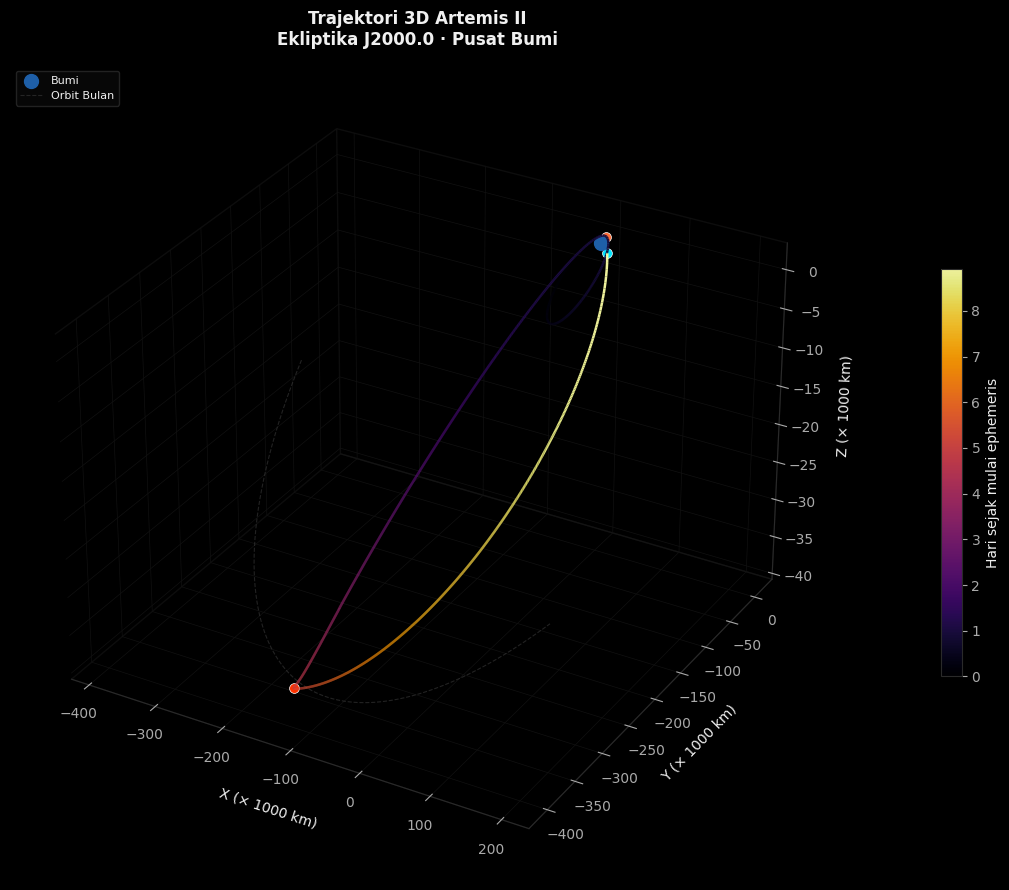

Disimpan: trajectory_3d.png


In [8]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('#000000')
fig.patch.set_facecolor('#000000')

days_arr = (orion['time'] - orion['time'].iloc[0]).dt.total_seconds().values / 86400
x = orion['x'].values / 1e3
y = orion['y'].values / 1e3
z = orion['z'].values / 1e3

from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection

points = np.array([x, y, z]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
norm = plt.Normalize(days_arr.min(), days_arr.max())
lc = Line3DCollection(segments, cmap='inferno', norm=norm, linewidth=1.8, alpha=0.95)
lc.set_array(days_arr[:-1])
ax.add_collection3d(lc)

# Earth
ax.scatter([0], [0], [0], color='#1E5FA8', s=100, zorder=5, label='Bumi')

# Moon orbit
ax.plot(moon['x'] / 1e3, moon['y'] / 1e3, moon['z'] / 1e3,
        '--', color='#444444', linewidth=0.8, alpha=0.5, label='Orbit Bulan')

# Key points
for label, t_str, color in [
    ('TLI', '2026-04-02 23:49', '#FF6B35'),
    ('Closest\nApproach', '2026-04-06 23:01', '#FF3300'),
    ('Splashdown', '2026-04-11 00:00', '#00E5FF'),
]:
    r = get_orion_at(t_str)
    ax.scatter([r['x']/1e3], [r['y']/1e3], [r['z']/1e3],
               color=color, s=50, zorder=6, edgecolors='white', linewidths=0.5)

ax.set_xlabel('X (× 1000 km)', labelpad=8)
ax.set_ylabel('Y (× 1000 km)', labelpad=8)
ax.set_zlabel('Z (× 1000 km)', labelpad=8)
ax.set_title('Trajektori 3D Artemis II\nEkliptika J2000.0 · Pusat Bumi',
             fontsize=12, pad=15, color='#F0F0F0', fontweight='bold')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('#1A1A1A')
ax.yaxis.pane.set_edgecolor('#1A1A1A')
ax.zaxis.pane.set_edgecolor('#1A1A1A')
ax.tick_params(colors='#AAAAAA')
ax.legend(loc='upper left', fontsize=8)

cbar = fig.colorbar(lc, ax=ax, shrink=0.5, pad=0.1, label='Hari sejak mulai ephemeris')
cbar.ax.yaxis.label.set_color('#F0F0F0')
cbar.ax.tick_params(colors='#AAAAAA')
plt.tight_layout()
plt.savefig('trajectory_3d.png', dpi=150, bbox_inches='tight', facecolor='#000000')
plt.show()
print("Disimpan: trajectory_3d.png")

## 7. Ringkasan Statistik Misi

In [9]:
idx_max_earth = orion['dist_earth'].idxmax()
idx_min_moon  = orion['dist_moon'].idxmin()
idx_max_speed = orion['speed'].idxmax()
idx_min_speed = orion['speed'].idxmin()

print("="*55)
print(" RINGKASAN STATISTIK MISI ARTEMIS II")
print("="*55)
print(f" Jarak maks dari Bumi  : {orion.loc[idx_max_earth, 'dist_earth']:>12,.1f} km")
print(f"   pada               : {orion.loc[idx_max_earth, 'time']}")
print()
print(f" Jarak min dari Bulan  : {orion.loc[idx_min_moon, 'dist_moon']:>12,.1f} km")
print(f"   pada               : {orion.loc[idx_min_moon, 'time']}")
print()
print(f" Kecepatan tertinggi   : {orion.loc[idx_max_speed, 'speed']:>12.4f} km/s")
print(f"   pada               : {orion.loc[idx_max_speed, 'time']}")
print()
print(f" Kecepatan terendah    : {orion.loc[idx_min_speed, 'speed']:>12.4f} km/s")
print(f"   pada               : {orion.loc[idx_min_speed, 'time']}")
print()
print(f" Total titik data      : {len(orion):>12,} ({len(orion)*5} menit = {len(orion)*5/1440:.1f} hari)")
print("="*55)

 RINGKASAN STATISTIK MISI ARTEMIS II
 Jarak maks dari Bumi  :    413,144.2 km
   pada               : 2026-04-06 23:03:32.305000

 Jarak min dari Bulan  :      8,282.7 km
   pada               : 2026-04-06 23:03:32.305000

 Kecepatan tertinggi   :      10.6543 km/s
   pada               : 2026-04-02 23:53:32.305000

 Kecepatan terendah    :       0.4136 km/s
   pada               : 2026-04-06 23:28:32.305000

 Total titik data      :        2,567 (12835 menit = 8.9 hari)


---

## Penutup

Data ephemeris yang digunakan dalam notebook ini adalah data nyata dari **NASA JPL Horizons System** yang diperbarui selama misi berlangsung. Trajektori Artemis II menunjukkan manuver *free-return*: jika semua sistem gagal pasca-TLI, gravitasi Bulan dan Bumi akan secara alami mengembalikan Orion ke Bumi.

Misi ini adalah langkah kedua program Artemis setelah Artemis I (tanpa awak, 2022). Artemis III direncanakan akan membawa manusia kembali ke permukaan Bulan untuk pertama kalinya sejak 1972.

---
**Data sumber:**
- Artemis II ephemeris: NASA JPL Horizons, body ID `-1024`, diperbarui 10 April 2026
- Moon ephemeris: NASA JPL Horizons, body ID `301`, DE441

**Kode sumber:** [github.com/yourusername/artemis-ii-analysis](https://github.com)
